# Medical Insurance Cost Prediction — Regression Analysis:

## 1. Introduction:

Healthcare costs are one of the most significant financial burdens faced by individuals
and families worldwide. The ability to accurately predict insurance charges based on
personal and lifestyle factors can help insurance companies price policies fairly, and
help individuals better understand what drives their premiums.

In this project, I perform an end-to-end regression analysis on the **Medical Cost
Personal Dataset**, which contains anonymous records of **1,338 individuals** including
demographic information, health indicators, and their annual insurance charges.

### Dataset Overview:

| Feature | Type | Description |
|---|---|---|
| age | Numerical | Age of the individual |
| sex | Categorical | Gender (male / female) |
| bmi | Numerical | Body Mass Index |
| children | Numerical | Number of dependents |
| smoker | Categorical | Smoking status (yes / no) |
| region | Categorical | Residential region in the US |
| charges | Numerical | Annual insurance charges (target) |

### Project Goals:
- Perform **Exploratory Data Analysis (EDA)** to uncover patterns and relationships in the data
- Preprocess and prepare the data for machine learning
- Build and compare **Multiple Linear Regression** and **Polynomial Regression** models
- Evaluate model performance using **R² Score**, **RMSE**, and **K-Fold Cross Validation**
- Draw meaningful, real-world conclusions from the results

# 2. Libraries used:

The following libraries are used throughout this project:
- **NumPy** — numerical computations
- **Pandas** — data manipulation and analysis
- **Matplotlib & Seaborn** — data visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print('All libraries are imported successfully')

All libraries are imported successfully


# 3. Mounting drive and importing dataset:

The dataset is loaded from Google Drive. We then perform a quick
initial check to confirm the data has loaded correctly.

## 3.1 - Mounting drive:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3.2 - Loading the dataset:

In [3]:
data = pd.read_csv('/content/drive/MyDrive/insurance.csv')
print('Data loaded successfully:')

print('Shape', data.shape)


Data loaded successfully:
Shape (1338, 7)


# 4. Data exploration:

In this section, we explore the structure and contents of the dataset
to understand what we are working with before making any changes.

In [4]:
# 4.1 - First 10 rows of the data:
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [5]:
# 4.2 - Last 5 rows of the data:
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


-  The dataset contains records of individuals with details such as age, sex,
BMI, number of children, smoking status, and region.
-  The target variable is **charges** — the annual insurance cost.
-  A quick glance at the first and last rows confirms the data has loaded correctly with no obvious formatting issues.

In [6]:
# 4.3 - Info about the dataset:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- The dataset contains **1,338 rows and 7 columns** with no null values in any
column.
- Numerical columns are age, bmi, children, and charges.
- Categorical columns are sex, smoker, and region, these will need to be encoded into numerical values before building any machine learning model.

In [7]:
# 4.4 - Statistical summary:
data.describe(include = 'all').round(2).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.21,14.05,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.66,6.1,15.96,26.3,30.4,34.69,53.13
children,1338.0,NaN,NaN,NaN,1.09,1.21,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.42,12110.01,1121.87,4740.29,9382.03,16639.91,63770.43


The dataset has no missing values across all 1,338 records.

Key insights:
- **Age** ranges from 18 to 64, with an average of 39 years
- **BMI** averages at 30.6, which falls in the obese category
- **Children** ranges from 0 to 5, with most individuals having 0 or 1
- **Charges** has a mean of $13,270 but a median of only $9,382 — indicating
  a right-skewed distribution driven by a small group of high-cost individuals
- Most individuals are **non-smokers** (1,064 out of 1,338)
- **Southeast** is the most common region (364 individuals)

In [8]:
# 4.5 - Missing values:

print('Missing values in entire dataset:',data.isnull().sum().sum())

print('\nMissing values in each columns:')
data.isnull().sum()



Missing values in entire dataset: 0

Missing values in each columns:


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


- No missing values were found in any column.
- The dataset is complete and
no imputation or dropping of rows is required at this stage.

# 5. DATA ANALYSIS & VISUALIZATION:

In this section, we explore relationships between features and insurance charges through visualizations.

## 5.1 - UNIVARIATE ANALYSIS:

Univariate Analysis — We analyze each feature individually to understand its distribution, spread, and shape

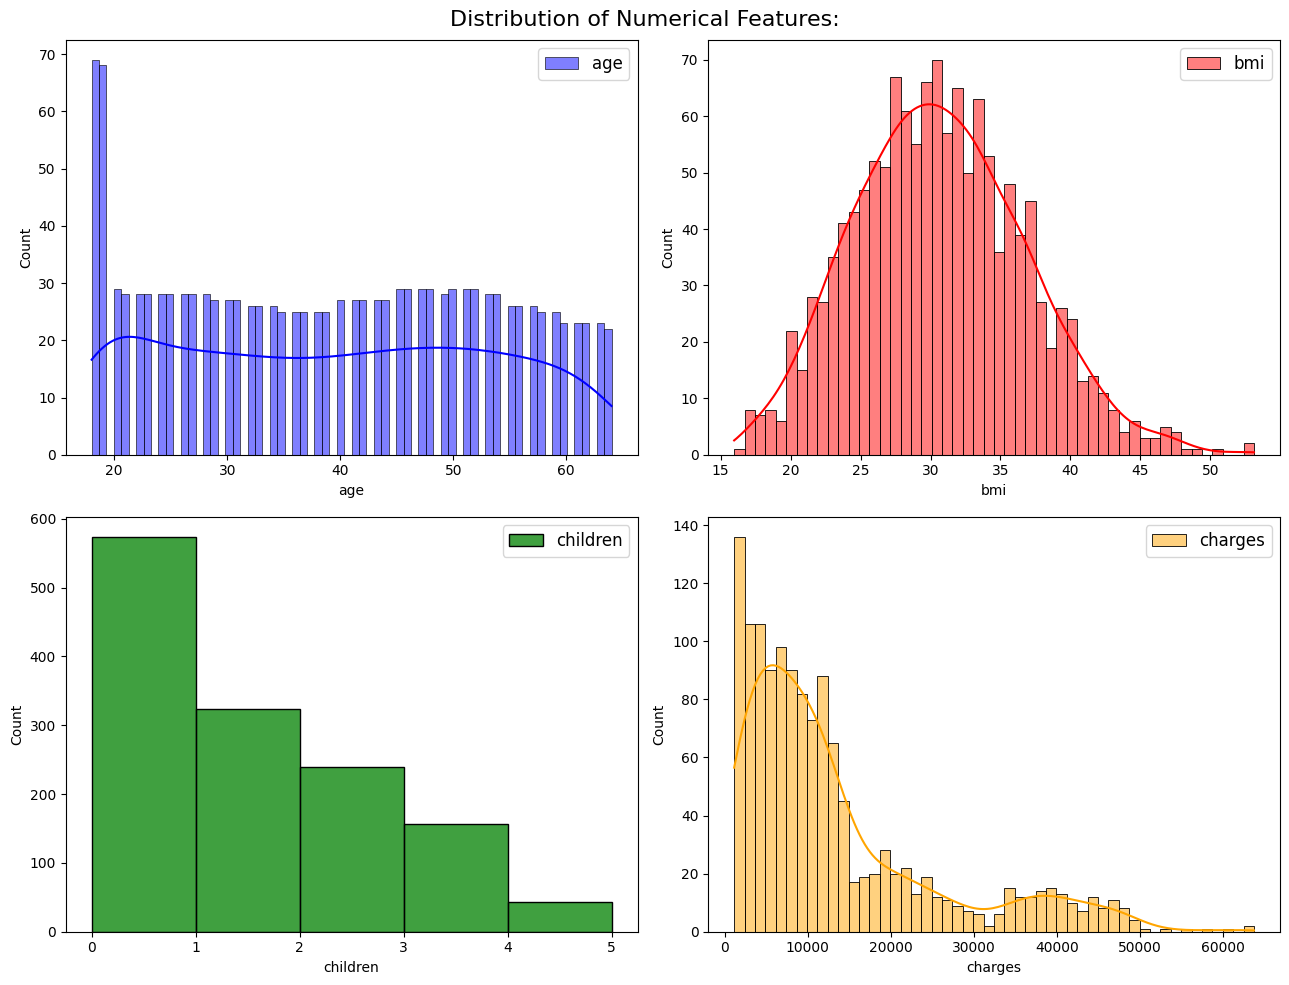

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 10))
plt.suptitle('Distribution of Numerical Features:', fontsize=16)

sns.histplot(data=data, x='age', bins=70, color='blue', ax=axes[0,0], kde=True, label='age')
sns.histplot(data=data, x='bmi', bins=50, color='red', ax=axes[0,1], kde=True, label='bmi')
sns.histplot(data=data, x='children', bins=5, color='green', ax=axes[1,0], label='children')
sns.histplot(data=data, x='charges', bins=50, color='orange', ax=axes[1,1], kde=True, label='charges')

axes[0,0].legend(fontsize=12)
axes[0,1].legend(fontsize=12)
axes[1,0].legend(fontsize=12)
axes[1,1].legend(fontsize=12)

plt.tight_layout()
plt.show()

**Histogram Summary:**
-  Age — Uniform distribution. Bars are roughly equal height across 18–64. No single age group dominates the dataset. The KDE line is nearly flat, confirming this.
- BMI — Normal distribution. Classic bell curve shape, centered around 30. Most people fall between 25–35. Symmetric on both sides.
- Children — Right skewed. Majority of people have 0 children (count ~575). Drops steeply as number of children increases. Very few people have 4 or 5 children.
- Charges — Heavily right skewed. Most charges are concentrated below $15,000. Long tail stretches all the way to $60,000+. This suggests a small group of people pay extremely high insurance — likely smokers.

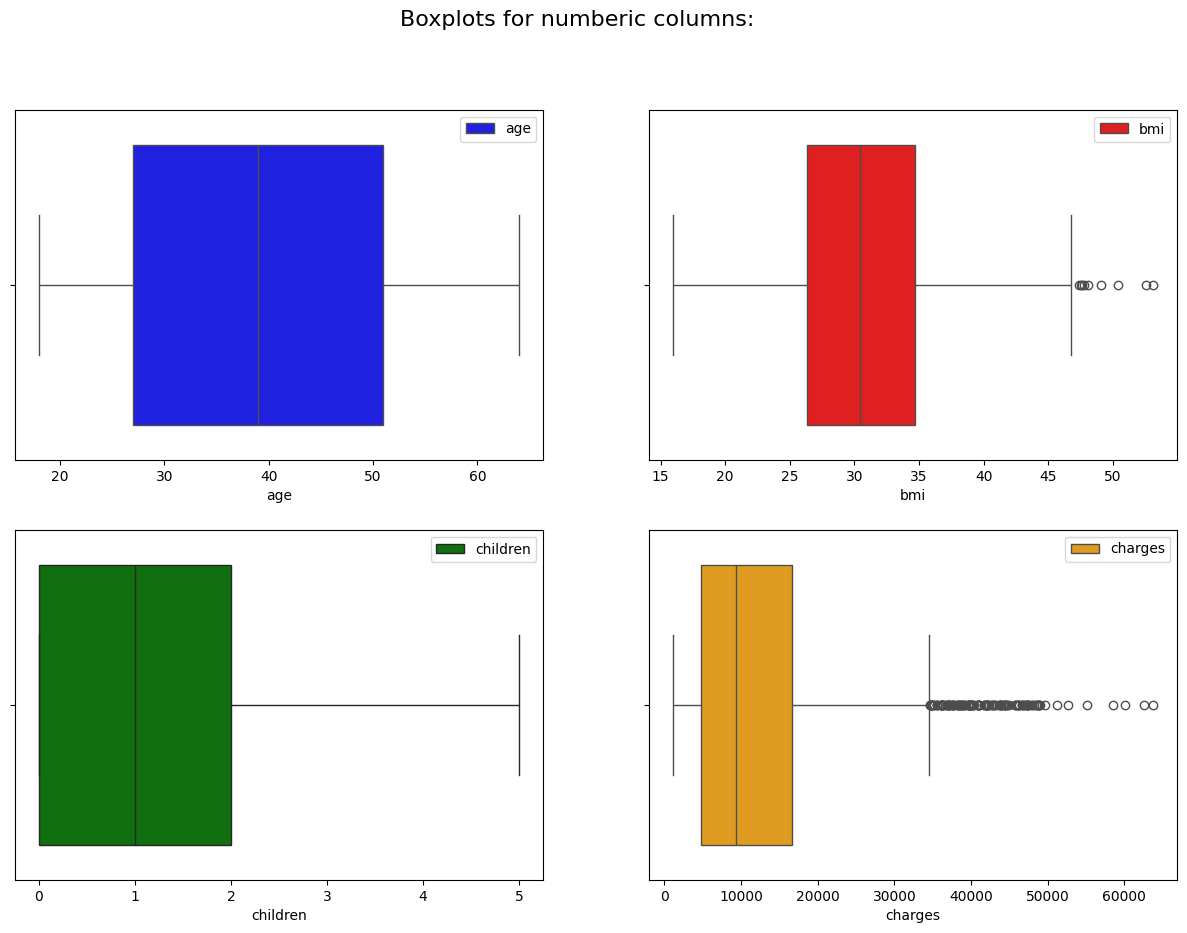

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
plt.suptitle('Boxplots for numberic columns:', fontsize =16)
sns.boxplot(data = data, x='age', color= 'b', ax=axes[0,0], label = 'age')
sns.boxplot(data = data, x='bmi', color = 'r', ax=axes[0,1], label= 'bmi')
sns.boxplot(data = data, x='children', color = 'g', ax=axes[1,0], label= 'children')
sns.boxplot(data = data, x='charges', color = 'orange', ax=axes[1,1], label = 'charges')
plt.show()




**Boxplot Summary:**
- Age — Median around 39. IQR spans roughly 27–51. Whiskers reach 18 and 64. No outliers at all — very clean, evenly spread data.
- BMI — Median around 30. IQR spans 26–35. A few outliers on the right side (BMI 50+), meaning some people are extremely obese but they are rare.
- Children — Median at 1. IQR spans 0–2. Whisker extends to 5. No outliers — all values are within expected range.
- Charges — Median around 9,000 dollars, IQR spans roughly $5,000 -  $16,000.

- Large number of outlier dots stretching to $60,000+. This wide spread and high outliers strongly suggest that smoking status creates two very different groups in this column.

<Axes: xlabel='smoker', ylabel='count'>

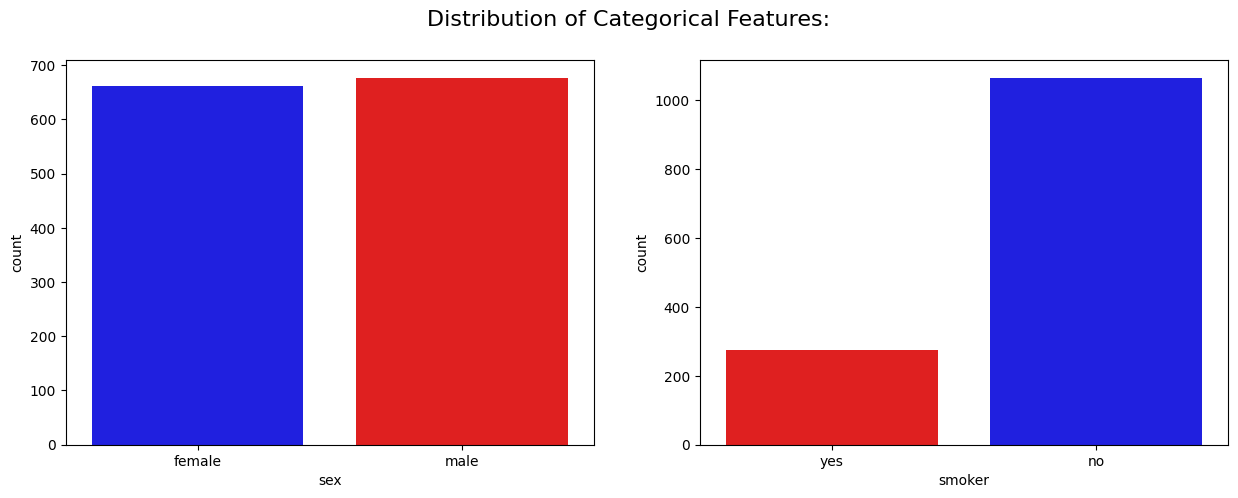

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
plt.suptitle('Distribution of Categorical Features:', fontsize=16)

sns.countplot(data = data, x = 'sex', ax=axes[0], hue='sex', palette={'male': 'r', 'female': 'b'})
sns.countplot(data = data, x = 'smoker', ax=axes[1], hue= 'smoker', palette={'yes': 'r', 'no': 'b'})


- Sex — Males (676) and females (662) are almost equal. The dataset is perfectly balanced by gender, so sex alone is unlikely to be a strong predictor of charges.
- Smoker — Non-smokers (1064) are roughly 4x more than smokers (274). Only about 20% of people smoke. This imbalance is important, that small 20% group is responsible for most of the high charge outliers we saw in the boxplot earlier
- Key Insight: The dataset is well balanced for sex, but imbalanced for smoker. This tells us that smoker will be the most powerful feature in our model, even though it represents a minority of the data

## 5.2 - BIVARIATE ANALYSIS:

We compare each feature against the target variable (charges) to see which features have a strong relationship with insurance cost.

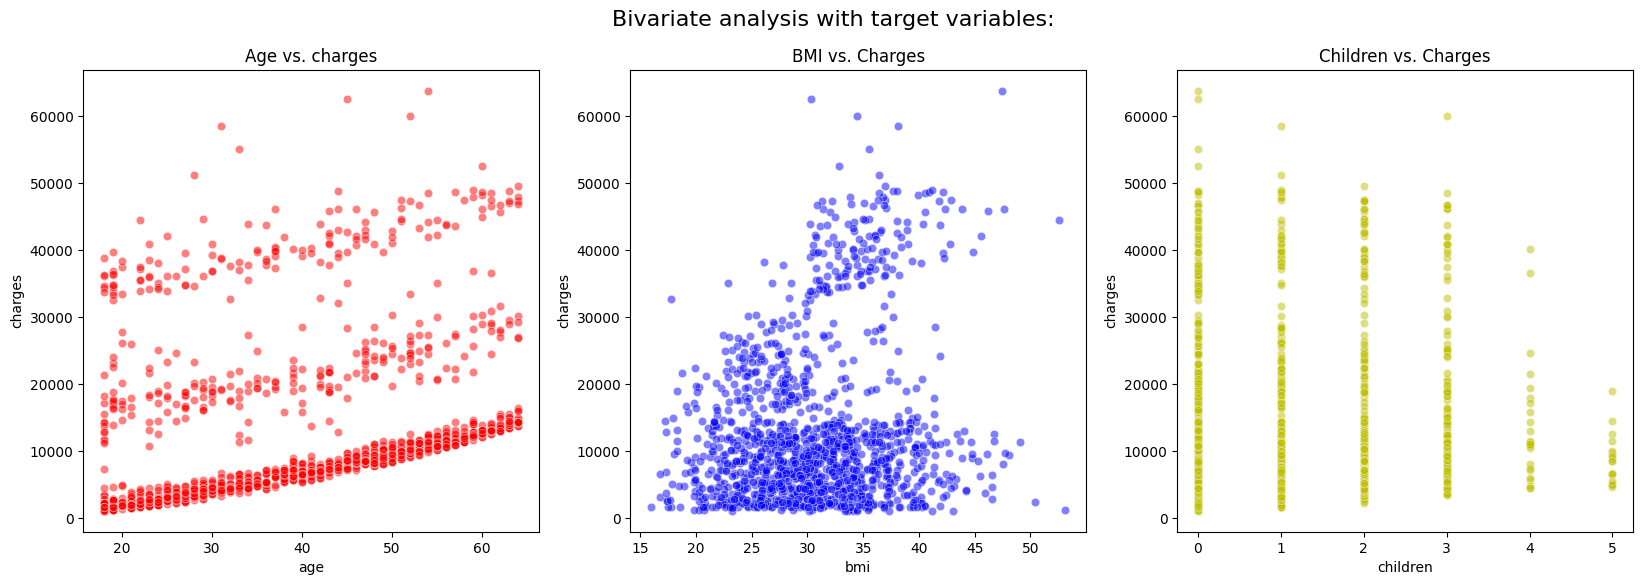

In [12]:
fig, axes= plt.subplots(nrows = 1, ncols = 3, figsize =(20,6))
plt.suptitle('Bivariate analysis with target variables:', fontsize = 16)

sns.scatterplot(data = data, x = 'age', y = 'charges', color = 'r', ax = axes[0], alpha = 0.5).set_title('Age vs. charges')
sns.scatterplot(data = data, x = 'bmi', y = 'charges', color = 'b', ax = axes[1], alpha = 0.5).set_title('BMI vs. Charges')
sns.scatterplot(data = data, x = 'children', y = 'charges', color = 'y', ax = axes[2], alpha = 0.5).set_title('Children vs. Charges')
plt.show()

- Age has the clearest individual relationship with charges.
- BMI and children are weak predictors on their own ,their true impact only shows up when combined with smoker status.
- This confirms that a simple single-feature model won't work well here; we need all features together.

## 5.3 - MULTIVARIATE ANALYSIS:

<Axes: xlabel='bmi', ylabel='charges'>

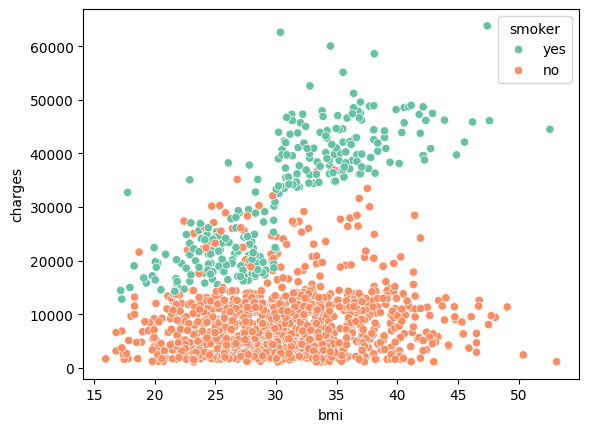

In [13]:
sns.scatterplot(x="bmi", y="charges", data=data, palette='Set2', hue='smoker')

- Non-smokers cluster tightly below $20,000 regardless of BMI, smoking absence keeps costs low

-  Smokers sit in a completely separate band starting from $20,000+, and their charges rise steeply as BMI increases.

- This reveals that smoking + high BMI together drive the highest insurance costs, neither factor alone tells the full story.

- smoker will be the strongest predictor in our regression model.

In [14]:
corr = data[['age', 'bmi', 'children', 'charges']].corr()
corr

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


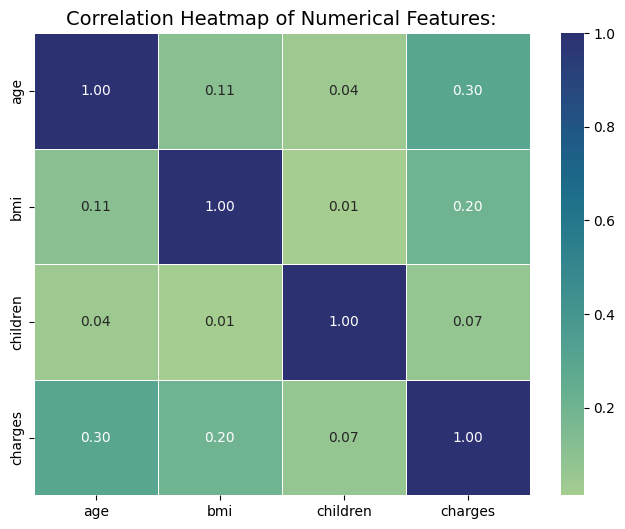

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.title('Correlation Heatmap of Numerical Features:', fontsize=14)
sns.heatmap(data=corr, annot=True, fmt='.2f', linewidths=0.5, cmap='crest', ax=ax)
plt.show()

- Age is the strongest numerical predictor of charges (0.30), followed by BMI (0.20).
- Children has negligible impact (0.07).
-  No multicollinearity exists between features, making this dataset clean for linear regression.

#6. DATA PREPROCESSING:

In this section, we prepare the data for machine learning. This includes dropping irrelevant columns, encoding categorical variables, splitting the data into features and target, dividing into train and test sets, and scaling numerical features.

## 6.1 - Drop irrelevant columns:
In this section, We drop the region column as it has no meaningful impact on predicting insurance charges:

In [16]:
data.drop(['region'], axis = 1, inplace = True)
data.shape


(1338, 6)

## 6.2 - Split Data and Target:
We can't give the whole dataset to the model as it is. First we need to set the data and target part of it. Here, the data part is called X, while the target part is called y. Now split the data and target partitions and assign each of them to variables named X and y:

In [17]:
X = data.drop(['charges'], axis = 1)
y = data['charges']

print('Shape of X:', X.shape)
print('Shape of Y:', y.shape)

Shape of X: (1338, 5)
Shape of Y: (1338,)


## 6.3 - Encoding categorical columns:

Here we will convert categorical data into numeric data. In our dataset, categorical columns are gender and smoking. We will convert them numerically:

* **GENDER :** If "male" is 0, "female" is 1.
* **SMOKER :** If "no" is 0, "yes" is 1.

In [18]:
X.head()

,age,sex,bmi,children,smoker
0,19,female,27.900,0,yes
1,18,male,33.770,1,no
2,28,male,33.000,3,no
3,33,male,22.705,0,no
4,32,male,28.880,0,no


In [19]:
X.sex = [1 if each == "female" else 0 for each in X.sex]
X.smoker = [1 if each == "yes" else 0 for each in X.smoker]
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


## 6.4 - Preparation of Test and Train Data:

We split the data into 80% training and 20% testing. The model learns from the training set and is evaluated on the test set, data it has never seen before. This gives us a fair measure of how well the model performs in the real world.

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (1070, 5)
X_test shape: (268, 5)
y_train shape: (1070,)
y_test shape: (268,)


## 6.5 - Feature Scaling:
Numerical columns like age, bmi, and children have very different value ranges. This can mislead the model into treating larger numbers as more important. We use MinMaxScaler to bring all three columns to the same 0–1 range so the model evaluates every feature fairly.

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train[['age', 'bmi', 'children']] = scaler.fit_transform(X_train[['age', 'bmi', 'children']])
X_test[['age', 'bmi', 'children']] = scaler.transform(X_test[['age', 'bmi', 'children']])

X_train.head()

,age,sex,bmi,children,smoker
560,0.608696,1,0.107345,0.4,0
1285,0.630435,1,0.224913,0.0,0
1142,0.739130,1,0.239440,0.0,0
969,0.456522,1,0.493947,1.0,0
486,0.782609,1,0.148238,0.6,0


In [22]:
X_test.head()

,age,sex,bmi,children,smoker
764,0.586957,1,0.247915,0.4,0
887,0.391304,1,0.378262,0.0,0
890,1.000000,1,0.293920,0.0,1
1293,0.608696,0,0.263250,0.6,0
259,0.021739,0,0.429379,0.0,1


**Data Preprocessing Summary:**

In this section, we prepared the data for machine learning in 5 steps:
- Dropped region — not useful for predicting charges
- Split X and y — separated input features from the target variable charges
- Encoded categorical columns — converted sex and smoker from text to numbers (0 and 1)
- Train test split — divided data into 80% training and 20% testing for fair model evaluation
-Feature scaling — applied MinMaxScaler on age, bmi, and children to bring them to the same 0–1 range, fitting only on training data to prevent data leakage

# 7. BUILDING MODELS:
In this section, we will build regression models and fit them wit data. The regression algorithms used in this section are:

1. Multiple Linear Regression
2. Polynomial Regression

## 7.1 - Multiple Linear Regression:

Create the Multiple Linear Regression model and fit the data:

In [23]:
from sklearn.linear_model import LinearRegression

# Create the model
MLR_model = LinearRegression()

# Train the model
MLR_model.fit(X_train, y_train)

print('Multiple Linear Regression model trained successfully')

Multiple Linear Regression model trained successfully


## 7.2 - Polynomial Regression:

In the Polynomial Regression model, we must first convert the data to the specified degree as a polynomial feature. For this, we will take advantage of the PolynomialFeatures class of the Scikit-Learn library. Now we will use the X data for training and testing as a polynomial feature and perform the fit process:

In [24]:
from sklearn.preprocessing import PolynomialFeatures

# Convert features to polynomial (degree 3)
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and train the model
PR_model = LinearRegression()
PR_model.fit(X_train_poly, y_train)

print('Polynomial Regression model trained successfully')

Polynomial Regression model trained successfully


- Multiple Linear Regression — learns a straight line relationship between the features and charges. Simple but limited when patterns are curved.
- Polynomial Regression — transforms the features into higher degree combinations before fitting, allowing it to capture curved and complex relationships in the data.
- Both models were trained on the same X_train and y_train data. Next we evaluate how well each model performed.

# 8. Model Evaluation:
In this section, we measure how well each model performed using three metrics:

- R² Score — measures accuracy, how much of the variation in charges the model correctly explained. Closer to 1 is better.
- RMSE — measures the average prediction error in dollars. Lower is better.
- 10-Fold Cross Validation — splits the data into 10 parts and tests the model 10 times for a more reliable and honest accuracy score.

We evaluate both models on training and testing data separately to check if the model learned well and generalizes to new unseen data.

In [25]:
from sklearn.model_selection import cross_val_score  # For K-Fold Cross Validation
from sklearn.metrics import r2_score  # For find accuracy with R2 Score
from sklearn.metrics import mean_squared_error  # For MSE
from math import sqrt  # For squareroot operation

## 8.1 — Evaluating Multiple Linear Regression:

In [26]:
# Predictions
y_pred_MLR_train = MLR_model.predict(X_train)
y_pred_MLR_test = MLR_model.predict(X_test)

# R2 Score
accuracy_MLR_train = r2_score(y_train, y_pred_MLR_train)
accuracy_MLR_test = r2_score(y_test, y_pred_MLR_test)

# RMSE
RMSE_MLR_train = np.sqrt(mean_squared_error(y_train, y_pred_MLR_train))
RMSE_MLR_test = np.sqrt(mean_squared_error(y_test, y_pred_MLR_test))

# Cross Validation
cv_MLR = cross_val_score(MLR_model, X_train, y_train, cv=10, scoring='r2')
accuracy_cv_MLR = cv_MLR.mean()

print('Training Accuracy:', accuracy_MLR_train)
print('Testing Accuracy:', accuracy_MLR_test)
print('Training RMSE:', RMSE_MLR_train)
print('Testing RMSE:', RMSE_MLR_test)
print('10-Fold CV Score:', accuracy_cv_MLR)

Training Accuracy: 0.7410888590280913
Testing Accuracy: 0.7811302113434097
Training RMSE: 6113.06655740958
Testing RMSE: 5829.172930254189
10-Fold CV Score: 0.730672708678331


## 8.2 — Evaluating Polynomial Regression:

In [27]:
# Predictions
y_pred_PR_train = PR_model.predict(X_train_poly)
y_pred_PR_test = PR_model.predict(X_test_poly)

# R2 Score
accuracy_PR_train = r2_score(y_train, y_pred_PR_train)
accuracy_PR_test = r2_score(y_test, y_pred_PR_test)

# RMSE
RMSE_PR_train = np.sqrt(mean_squared_error(y_train, y_pred_PR_train))
RMSE_PR_test = np.sqrt(mean_squared_error(y_test, y_pred_PR_test))

# Cross Validation
cv_PR = cross_val_score(PR_model, X_train_poly, y_train, cv=10, scoring='r2')
accuracy_cv_PR = cv_PR.mean()

print('Training Accuracy:', accuracy_PR_train)
print('Testing Accuracy:', accuracy_PR_test)
print('Training RMSE:', RMSE_PR_train)
print('Testing RMSE:', RMSE_PR_test)
print('10-Fold CV Score:', accuracy_cv_PR)

Training Accuracy: 0.8440044461603673
Testing Accuracy: 0.8640001614931049
Training RMSE: 4745.039861912811
Testing RMSE: 4594.975779183337
10-Fold CV Score: 0.8255105932059605


# 9. EXPLORATION OF RESULTS:

Here we bring all evaluation metrics together into a single comparison table. This gives a clear side by side view of how both models performed across training accuracy, testing accuracy, RMSE, and 10-Fold cross validation score — making it easy to identify which model is the better fit for this dataset.

In [28]:

results = {
    'Training Accuracy': [accuracy_MLR_train, accuracy_PR_train],
    'Testing Accuracy': [accuracy_MLR_test, accuracy_PR_test],
    'Training RMSE': [RMSE_MLR_train, RMSE_PR_train],
    'Testing RMSE': [RMSE_MLR_test, RMSE_PR_test],
    '10-Fold CV Score': [accuracy_cv_MLR, accuracy_cv_PR]
}

model_names = ['Multiple Linear Regression', 'Polynomial Regression']

results_table = pd.DataFrame(data=results, index=model_names)
results_table

,Training Accuracy,Testing Accuracy,Training RMSE,Testing RMSE,10-Fold CV Score
Multiple Linear Regression,0.741089,0.78113,6113.066557,5829.172930,0.730673
Polynomial Regression,0.844004,0.86400,4745.039862,4594.975779,0.825511


# 10. Conclusion:

In this project, I built and compared two regression models — **Multiple Linear Regression**
and **Polynomial Regression** — to predict annual medical insurance charges based on personal
and lifestyle factors.

---

## What I Found:

| Factor | Impact on Charges | Strength |
|---|---|---|
| Smoker | Smokers pay 3–4x more than non-smokers | Very Strong |
| Age | Charges steadily increase with age | Moderate |
| BMI + Smoking | Combined effect drives charges to $40,000–$60,000 | Very Strong |
| BMI alone | Weak predictor on its own | Weak |
| Children | Barely affects charges | Very Weak |
| Sex | Almost no difference between male and female | Very Weak |

---

## Model Performance:

Polynomial Regression outperformed Multiple Linear Regression across every metric:

- Testing Accuracy improved from **78.1% → 86.4%**
- Testing RMSE reduced from **$5,829 → $4,594**
- 10-Fold CV Score improved from **0.730 → 0.825**

---

## Why Polynomial Regression Won:

The insurance data has a curved, non-linear pattern — clearly visible in the BMI vs Charges
scatter plot colored by smoker status. A straight line simply cannot capture this curve.
Polynomial Regression bends to fit the actual shape of the data, resulting in 8% higher
accuracy and $1,235 less prediction error per person.

---

## Real World Impact:

- **Insurance Companies** — can automatically price policies based on a person's
  actual risk profile rather than broad assumptions
- **Individuals** — can understand exactly which lifestyle factors are driving
  their premiums and make informed decisions
- **Government Health Programs** — can forecast healthcare costs more accurately
  for budget planning and resource allocation

---

## Key Takeaway:

> If a person wants to reduce their insurance costs, the data gives one clear answer —
> stop smoking. It is by far the single most impactful lifestyle change a person can make.
> Age and children you cannot control, but smoking is a choice — and this dataset shows
> exactly how expensive that choice is.

---